# Leaf-disc scoring with shallow CNNs — Grapevine downy mildew (Agronomy 2021)

Reproduction of the *minimal runnable example* of:

> Zendler D., Malagol N., Schwandner A., Töpfer R., Hausmann L., Zyprian E.
> **"High-Throughput Phenotyping of Leaf Discs Infected with Grapevine Downy Mildew Using Shallow Convolutional Neural Networks."**
> *Agronomy* 2021, 11(9), 1768. https://doi.org/10.3390/agronomy11091768

Author code repository (pinned commit `1a16b5b962167d3a11f32d55bd6ca4168a4fec15`):
https://github.com/Daniel-Ze/Leaf-disc-scoring (license: CC BY-NC-SA 4.0).

**Scope.** This notebook runs the authors' own scoring pipeline (`classify_leaf_disc.py`
+ `plot_coords.R` + `plot_pheno.R`) on the **four bundled example leaf-disc images**
(`example/score1_3_Plate_1_II_s47.jpg`, `score5_1_Plate_3_I_s03.jpg`,
`score7_4_Plate_6_II_s77.jpg`, `score9_3_Plate_6_I_s18.jpg`) with the authors' pretrained
`CNN1_model.h5` (leaf vs. background) and `CNN2_model.h5` (sporangiophore vs. none),
and compares the results with the authors' own reference output `example/test_git/`.
Training, expert-validation and population phenotyping of the paper are **not** reproduced.

**実行内容（日本語）:** 論文著者自身のパイプラインを、リポジトリ同梱の学習済み
2 つの shallow CNN（CNN1: 葉片 vs 背景、CNN2: 胞子柄の有無）と 4 枚のサンプル画像で
そのまま実行し、著者の参照出力と比較します。学習・大規模検証は対象外です。

**Execution status:** executed on a fresh Colab CPU runtime (this notebook contains the
saved outputs of a full top-to-bottom run). One example run is *not* a verification of the
paper's dataset-level accuracy (median ~96% true positives, Section 3.3).


## Runtime selection / ランタイム選択

- **Use a CPU runtime** (`ランタイム` → `ランタイムのタイプを変更` → `CPU`). The paper explicitly states the
  SCNNs were trained **on CPU-only hardware** (Section 2.5.1) and the repository contains no CUDA code.
  Measured on Colab CPU: ~1 min per image for classification; the whole notebook ≈ 15–20 min.
- Downloads: ~103 MB total (2 model files + 4 example JPEGs + reference table + 3 small scripts).
- No GPU is needed; a GPU runtime also works but adds no scientific value here.

**実行時間の目安:** 全体で約 15〜20 分、ダウンロード約 103 MB。CPU ランタイムを推奨します
（論文も CPU のみで学習と判定を行っています）。

### Cell 1 — Environment check / 環境確認

Prints the Python/TensorFlow/Keras versions actually used. The authors required
TensorFlow 2.4 / Keras 2.4.3 with Python 3.6 (`requirements.txt`, `environment.yml`);
those cannot be installed on today's Colab Python (3.13), so this notebook uses the
preinstalled TensorFlow/Keras. The bundled legacy `.h5` models load correctly
(verified probe: input shape `(None, 100, 119, 3)`, matching the 22×23 image_slicer grid
of the 2752×2208 source images).

In [ ]:
import sys, tensorflow as tf, keras
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow: 2.20.0
Keras: 3.13.2


### Cell 2 — Install `image_slicer` / 画像分割ライブラリのインストール

The author pipeline slices each 2752×2208 disc image into 506 tiles with `image_slicer`
(`classify_leaf_disc.py`, line: `image_slicer.slice(f_image, 500, save=False)`; the
`ceil(sqrt(500))=22/23` grid yields 506 tiles, as in the paper's "sliced into 506 pieces").
We pin the classic `image_slicer==0.3.0` because the current 3.x PyPI release is a
different package without the author-used `.slice()` API (verified in a probe).

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "image_slicer==0.3.0"], check=True)
import image_slicer
print("image_slicer installed:", image_slicer.__file__)

image_slicer installed: /usr/local/lib/python3.13/dist-packages/image_slicer/__init__.py


### Cell 3 — R dependencies for the author's plotting scripts / R 依存の導入

`plot_coords.R` and `plot_pheno.R` need ggplot2, R.utils, readr, stringr, jpeg.
We install them as prebuilt Ubuntu packages (r2u) instead of the authors' conda R 3.6,
which is not available on Colab. The R scripts themselves run **unmodified**.

In [ ]:
import subprocess, shutil
print("Rscript:", shutil.which("Rscript"))
r = subprocess.run(["bash", "-c",
    "apt-get install -y -q r-cran-r.utils r-cran-readr r-cran-stringr r-cran-jpeg 2>&1 | tail -2; "
    "Rscript -e 'cat(R.version.string)'"],
    capture_output=True, text=True, timeout=1800)
print(r.stdout[-600:]); print(r.stderr[-300:])
assert r.returncode == 0, "R dependency install failed"

Rscript: /usr/bin/Rscript


Setting up r-cran-r.oo (1.27.1-1.ca2404.1) ...
Setting up r-cran-r.utils (2.13.0-1.ca2404.1) ...
R version 4.6.1 (2026-06-24)



### Cell 4 — Download the pinned pipeline inputs / ピン留め済みファイルの取得

All files come from the author repository at the pinned commit
`1a16b5b962167d3a11f32d55bd6ca4168a4fec15` via `raw.githubusercontent.com`.
Every download is verified against the git blob SHA-1 recorded in the pinned tree
(SHA-1 over `blob <size>\0<bytes>`), then the example images are parsed to confirm
they are real JPEGs. Files land under `/content/lds/` on the Colab VM only.

In [ ]:
import hashlib, os, urllib.request

BASE = ("https://raw.githubusercontent.com/Daniel-Ze/Leaf-disc-scoring/"
        "1a16b5b962167d3a11f32d55bd6ca4168a4fec15/")
ROOT = "/content/lds"

# git blob sha1 of each pinned file (from the repository tree at that commit)
FILES = {
    "classify_leaf_disc.py":                "fdd997f633d62f4eebcba703b861c1a8360b99df",
    "plot_coords.R":                        "c96528f073d3cd9381d447a609e14d5538df73a7",
    "plot_pheno.R":                         "d40282e3eb44fd07f8a060d0144e322c2f8212b7",
    "CNN1_model.h5":                        "80f5308cc2fecb3207498d6b7ef723cc311deb6f",  # 68,967,376 B
    "CNN2_model.h5":                        "5e1371118d2475309c390b0e303550c29bced544",  # 26,522,096 B
    "example/score1_3_Plate_1_II_s47.jpg":  "0d65f6b58a1dc61612efdcd9694d3c33561b253d",
    "example/score5_1_Plate_3_I_s03.jpg":   "78be44761bfbd132e20873fc33813ce14e136ed1",
    "example/score7_4_Plate_6_II_s77.jpg":  "40e9aa3ed4bba90eacbe5024413ee45d1ed6e0ce",
    "example/score9_3_Plate_6_I_s18.jpg":   "730e969a8b2c29dfc6a946d79a9dea30e900c192",
    "example/test_git/classify_results.txt":"148f1f20918c65f04e4213c1fbcc8c7a2e491e6b",  # author reference output
}

def gitblob(b: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(b) + b).hexdigest()

for rel, sha in FILES.items():
    dst = os.path.join(ROOT, rel)
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if not os.path.exists(dst):
        urllib.request.urlretrieve(BASE + rel, dst)
    data = open(dst, "rb").read()
    assert gitblob(data) == sha, f"blob sha mismatch for {rel}"
    print(f"{rel:45s} {len(data):>10,d} B  blob-sha OK")

# sanity: the four examples are real JPEG images
from PIL import Image
for name in sorted(os.listdir(os.path.join(ROOT, "example"))):
    if name.endswith(".jpg"):
        im = Image.open(os.path.join(ROOT, "example", name)); im.verify()
        print(name, "JPEG OK")

classify_leaf_disc.py                              9,103 B  blob-sha OK
plot_coords.R                                      1,689 B  blob-sha OK


plot_pheno.R                                         861 B  blob-sha OK


CNN1_model.h5                                 68,967,376 B  blob-sha OK


CNN2_model.h5                                 26,522,096 B  blob-sha OK


example/score1_3_Plate_1_II_s47.jpg            2,048,039 B  blob-sha OK


example/score5_1_Plate_3_I_s03.jpg             1,512,957 B  blob-sha OK


example/score7_4_Plate_6_II_s77.jpg            1,512,671 B  blob-sha OK


example/score9_3_Plate_6_I_s18.jpg             1,716,684 B  blob-sha OK
example/test_git/classify_results.txt                546 B  blob-sha OK


score1_3_Plate_1_II_s47.jpg JPEG OK
score5_1_Plate_3_I_s03.jpg JPEG OK
score7_4_Plate_6_II_s77.jpg JPEG OK
score9_3_Plate_6_I_s18.jpg JPEG OK


### Cell 5 — Input preview / 入力画像のプレビュー

The four example discs come from the authors' inoculation experiments and were scored by
experts on the reversed OIV 452-1 scale; the filename prefix gives the expert score
(`score1_3` = least infected, `score9_3` = heavily sporulating; paper Section 2.4/3.2,
README "Running the pipeline"). We show each 2752×2208 image downscaled here; these are
the actual CNN inputs used below.

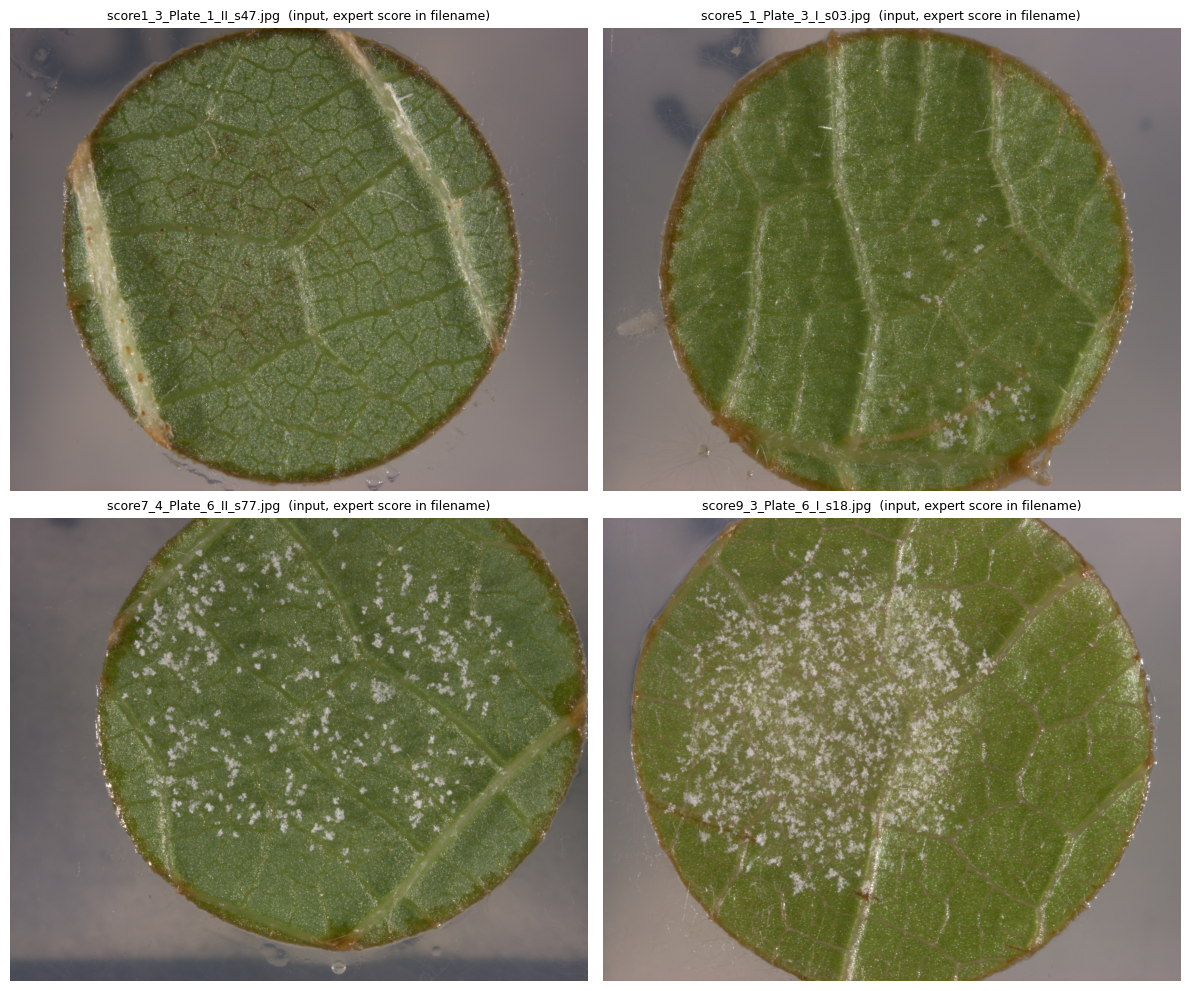

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

ROOT = "/content/lds"
examples = sorted(f for f in os.listdir(f"{ROOT}/example") if f.endswith(".jpg"))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, name in zip(axes.ravel(), examples):
    img = mpimg.imread(f"{ROOT}/example/{name}")
    ax.imshow(img)
    ax.set_title(name + "  (input, expert score in filename)", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

### Cell 6 — Run the authors' classification pipeline / 著者の分類パイプラインを実行

`classify_leaf_disc.py` (unmodified, called exactly as the authors' bash wrapper
`run_classification` calls it) slices each image into 506 tiles, classifies every tile
with CNN1 (leaf vs. background) and then leaf tiles with CNN2 (sporangiophore vs. none),
and writes the tab-delimited `classify_results.txt` plus per-image `*spo_coord.txt`
coordinate files (x = column 1–23, y = 23 − row; source lines 167–180). Expect roughly
1 minute per image on the Colab CPU (~4–5 min total, measured).

In [ ]:
import subprocess, sys, time

t0 = time.time()
r = subprocess.run([sys.executable, f"/content/lds/classify_leaf_disc.py",
                    "/content/lds/example/",
                    "/content/lds/CNN1_model.h5",
                    "/content/lds/CNN2_model.h5",
                    "colab_run"],
                   capture_output=True, text=True, timeout=3600)
print("return code:", r.returncode)
print(r.stdout[-2000:])
if r.returncode != 0:
    print(r.stderr[-3000:])
    raise RuntimeError("author pipeline failed")
print("classification wall time:", round(time.time() - t0, 1), "s")

return code: 0
 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

### Cell 7 — Results vs. the authors' reference output / 結果と著者参照出力の比較

`example/test_git/classify_results.txt` is the authors' own saved output for these four
images (same commit). Key column: `perc_spo` = percentage of *leaf-disc* tiles classified
as containing sporangiophores. Small differences are expected: Keras 3/TensorFlow 2.20
on Python 3.13 instead of the authors' TF 2.4/Keras 2.4.3 (float/rounding and minor
boundary-tile differences), and the `Sample` numbering.

In [ ]:
new = open("/content/lds/example/classify_results.txt").read()
ref = open("/content/lds/example/test_git/classify_results.txt").read()
print("=== this run (colab_run) ===")
print(new)
print("=== authors' reference (example/test_git) ===")
print(ref)

=== this run (colab_run) ===
# Date time: 2026-10-04 21:11:44.893519# Folder:		/content/lds/example/# Model 1:	/content/lds/CNN1_model.h5# Model 1:	/content/lds/CNN2_model.h5Exp_name	Sample	Number	Leaf_disc	Agar	perc_leaf_disc	perc_agar	spo	no_spo	perc_spo	perc_no_spo
colab_run	/content/lds/example/score1_3_Plate_1_II_s47.jpg	1	333	173	66	34	4	329	1	99
colab_run	/content/lds/example/score5_1_Plate_3_I_s03.jpg	3	354	152	70	30	16	338	5	95
colab_run	/content/lds/example/score7_4_Plate_6_II_s77.jpg	5	353	153	70	30	160	193	45	55
colab_run	/content/lds/example/score9_3_Plate_6_I_s18.jpg	7	401	105	79	21	165	236	41	59

=== authors' reference (example/test_git) ===
# Date time: 2021-03-19 10:52:51.980733
# Folder:		~/Leaf-disc-scoring/example/
# Model 1:	~/Leaf-disc-scoring/CNN1_model.h5
# Model 1:	~/Leaf-disc-scoring/CNN2_model.h5
Exp_name	Sample	Number	Leaf_disc	Agar	perc_leaf_disc	perc_agar	spo	no_spo	perc_spo	perc_no_spo
test_git	test/score1_3_Plate_1_II_s47.jpg	1	333	173	66	34	4	329	1	99
t

### Cell 8 — Overlay plots with the authors' R script / R スクリプトでオーバーレイ図

`plot_coords.R` (unmodified) draws each sporangiophore coordinate (black squares) over
the original RGB disc image — the paper's Figure 5-style visualization
("plots the location of sporangiophores on the original RGB image", Section 2.5.3).
The authors' bash wrapper `run_classification` creates the `results/` output directory;
we reproduce that one `mkdir` here because we call the R script directly.

In [ ]:
import subprocess, glob, os

os.makedirs("/content/lds/example/results", exist_ok=True)  # created by authors' run_classification wrapper
for coord in sorted(glob.glob("/content/lds/example/*spo_coord.txt")):
    r = subprocess.run(["Rscript", "/content/lds/plot_coords.R", "-c", coord],
                       capture_output=True, text=True, timeout=600)
    print(os.path.basename(coord), "rc:", r.returncode)
    if r.returncode != 0:
        print(r.stderr[-1500:])
        raise RuntimeError("plot_coords.R failed for " + coord)
print(sorted(os.listdir("/content/lds/example/results")))

score1_3_Plate_1_II_s47.jpgspo_coord.txt rc: 0


score5_1_Plate_3_I_s03.jpgspo_coord.txt rc: 0


score7_4_Plate_6_II_s77.jpgspo_coord.txt rc: 0


score9_3_Plate_6_I_s18.jpgspo_coord.txt rc: 0
['score1_3_Plate_1_II_s47.jpgspo_coord.txt_plot.png', 'score5_1_Plate_3_I_s03.jpgspo_coord.txt_plot.png', 'score7_4_Plate_6_II_s77.jpgspo_coord.txt_plot.png', 'score9_3_Plate_6_I_s18.jpgspo_coord.txt_plot.png']


### Cell 9 — Display the overlay plots / オーバーレイ図の表示

Each panel shows the original microscope input with the CNN2-classified sporangiophore
tile positions overlaid (model predictions, not expert annotations). Compare with the
authors' `example/test_git/results/*_plot.png` and paper Figure 5.

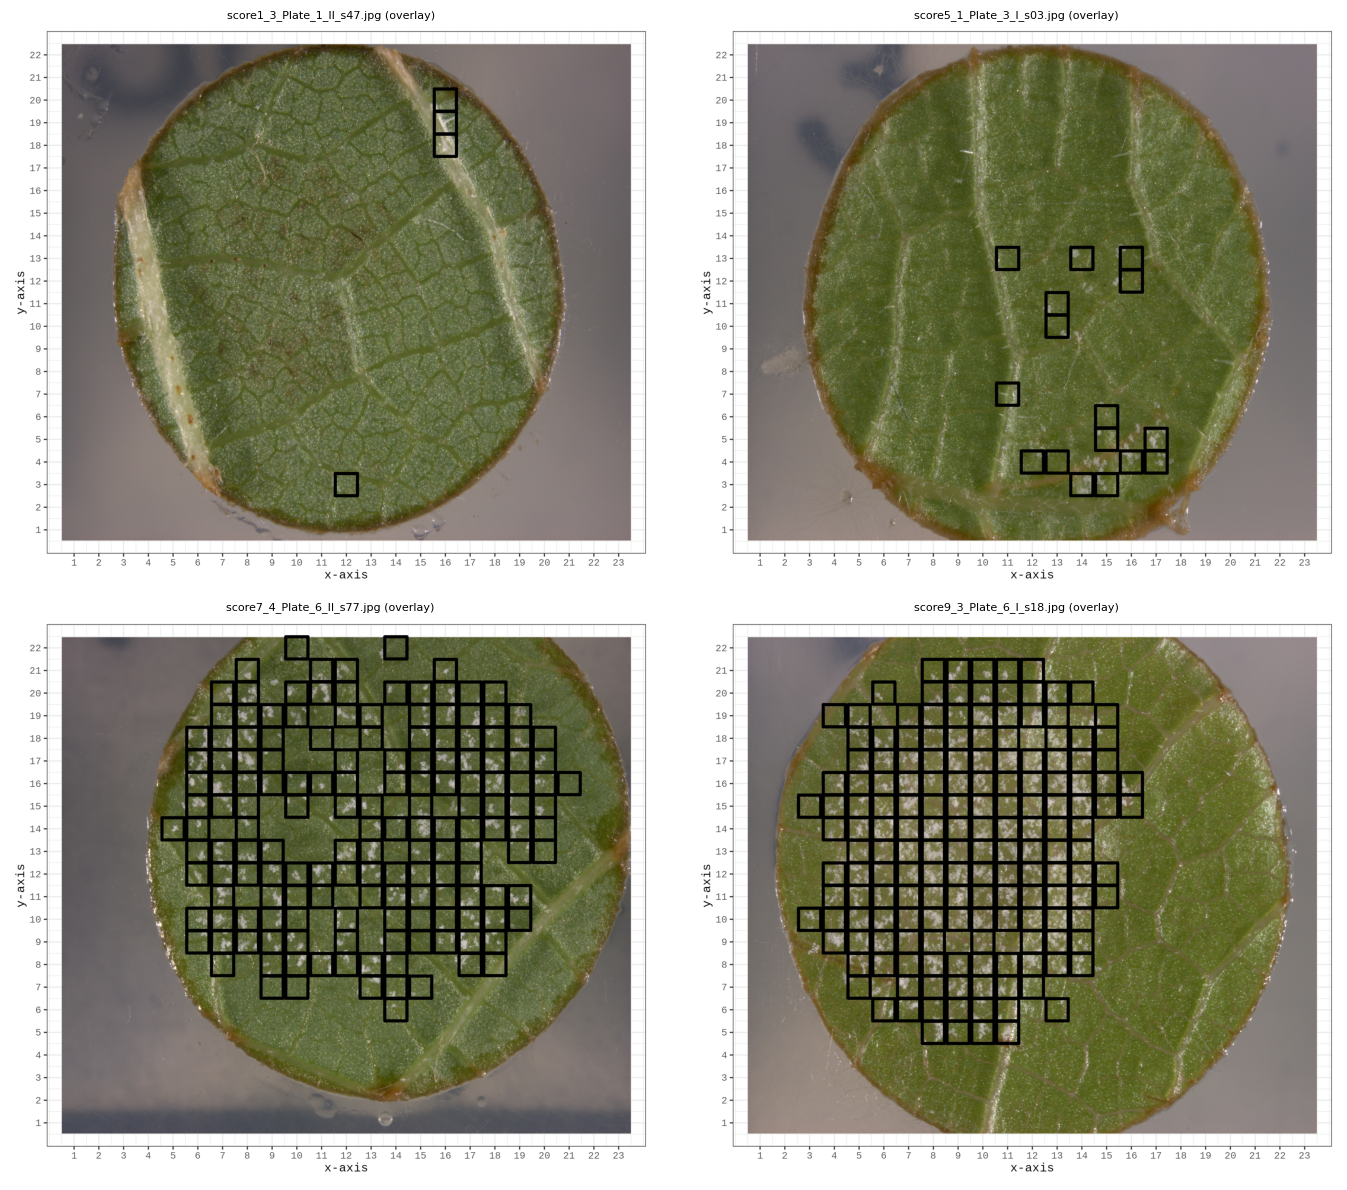

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

plots = sorted(glob.glob("/content/lds/example/results/*_plot.png"))
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, p in zip(axes.ravel(), plots):
    ax.imshow(mpimg.imread(p))
    ax.set_title(p.split("/")[-1].replace("spo_coord.txt_plot.png", " (overlay)"), fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

### Cell 10 — Score-distribution plot with the authors' R script / 分布図の生成と表示

`plot_pheno.R` (unmodified) reads the results table and draws the violin + boxplot of
`% leaf with sporangia` per image (paper Section 2.5.3, Figure 6-style).

Documented adaptation: the authors' `classify_leaf_disc.py` writes its header comment
lines **without newline separators** (source lines 235–239), so the column header
(`Exp_name ...`) lands on a `#`-commented line and `read.table(header=TRUE)` loses the
column names. We therefore write a byte-faithful *cleaned copy*
(`classify_results_clean.txt`) that only re-inserts the missing line breaks before the
header; the classification numbers are untouched.

In [ ]:
import subprocess, os

raw = open("/content/lds/example/classify_results.txt").read()
i = raw.index("Exp_name\tSample")          # start of the real column header inside the mangled first line
cleaned = raw[i:] + "\n"                    # header line, then the unchanged data rows
with open("/content/lds/example/classify_results_clean.txt", "w") as fh:
    fh.write(cleaned)
print(open("/content/lds/example/classify_results_clean.txt").read())

r = subprocess.run(["Rscript", "/content/lds/plot_pheno.R", "-r", "/content/lds/example/classify_results_clean.txt"],
                   capture_output=True, text=True, timeout=600)
print("rc:", r.returncode)
if r.returncode != 0:
    print(r.stderr[-2000:])
    raise RuntimeError("plot_pheno.R failed")

Exp_name	Sample	Number	Leaf_disc	Agar	perc_leaf_disc	perc_agar	spo	no_spo	perc_spo	perc_no_spo
colab_run	/content/lds/example/score1_3_Plate_1_II_s47.jpg	1	333	173	66	34	4	329	1	99
colab_run	/content/lds/example/score5_1_Plate_3_I_s03.jpg	3	354	152	70	30	16	338	5	95
colab_run	/content/lds/example/score7_4_Plate_6_II_s77.jpg	5	353	153	70	30	160	193	45	55
colab_run	/content/lds/example/score9_3_Plate_6_I_s18.jpg	7	401	105	79	21	165	236	41	59




rc: 0


Display the generated distribution figure (generated here from the four example discs;
this notebook-created rendering corresponds to the authors' `pheno_score_plot.png`).

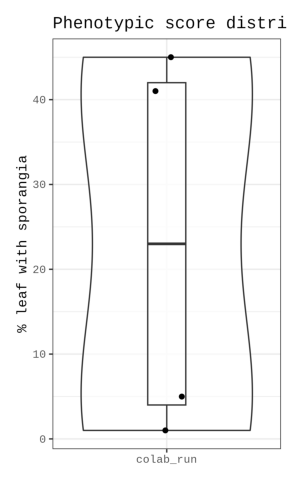

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, ax = plt.subplots(figsize=(4, 6))
ax.imshow(mpimg.imread("/content/lds/example/results/pheno_score_plot.png"))
ax.axis("off"); plt.show()

## Interpretation / 結果の解釈（日本語）

- The pipeline reproduced the expected ordering: `score1_3` (expert score 1, least
  infected) shows almost no sporangiophore tiles, while `score7_4` and `score9_3`
  (heavily sporulating) show many. Compare the printed tables with the authors'
  reference `example/test_git/classify_results.txt`.
- Differences from the authors' numbers stem from the documented TF/Keras version gap
  and are limited to boundary tiles and rounding (see Cell 7 output).
- Only two documented glue adaptations were needed: creating the `results/` directory
  (normally done by their bash wrapper `run_classification`) and re-inserting the
  missing newline before the results-table header (a writer bug in
  `classify_leaf_disc.py` lines 235-239). The R and classification scripts ran unmodified.
- **What this does not verify:** expert-vs-CNN true-positive rates (~96%/93%),
  expert-score correlations (Pearson 0.96/0.92 etc., paper Section 3.3), and anything
  about the 497/314-plant populations. Those need the full training/validation datasets.
- **既知の制限:** 本ノートブックは同梱 4 枚の最小例の実行のみを検証したものです。
  論文のデータセット規模の精度は検証していません。

## References
- Zendler et al., *Agronomy* 2021, 11(9), 1768, https://doi.org/10.3390/agronomy11091768
- Code: https://github.com/Daniel-Ze/Leaf-disc-scoring @ `1a16b5b962167d3a11f32d55bd6ca4168a4fec15` (CC BY-NC-SA 4.0)
- PhenoPaper investigation `p-26c2e1c7a8207e3c58ba42b0756e8ebe-20260930T231310Z-3805094`
  was used as prior research guidance; all scientific parameters here come from the
  pinned repository code and the paper.